# Customer Churn Intelligence

## Exploratory Data Analysis

This notebook analyzes customer behavior, churn patterns, service usage, payment methods, and customer risk indicators using the cleaned Telco Customer Churn dataset.

### Project Objectives

- Understand the overall customer churn rate.
- Identify customer groups with higher churn risk.
- Analyze churn across contracts, services, tenure, and payment methods.
- Generate business-focused insights and retention recommendations.

In [2]:
# Import the required libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Improve table display inside Jupyter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)


# Set a clean chart theme

sns.set_theme(
    style="whitegrid",
    context="notebook"
)


print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# Define the exact path to the cleaned dataset

from pathlib import Path

data_path = Path(
    r"C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\data\telco_customer_churn_clean.csv"
)


# Check that the file exists

print("File exists:", data_path.exists())


# Load the cleaned dataset

df = pd.read_csv(
    data_path,
    encoding="utf-8"
)


print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

File exists: True
Dataset loaded successfully.
Number of rows: 7,043
Number of columns: 33


In [7]:
# Preview the first five customer records

df.head()

,customer_id,customer_count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,"3,046.05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,"5,036.30",Yes,1,89,5340,Competitor had better devices


In [8]:
# Inspect dataset dimensions and data types

print(f"Dataset shape: {df.shape}")

print("\nDataset information:\n")

df.info()

Dataset shape: (7043, 33)

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   customer_count     7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043

In [9]:
# Check for duplicate customer IDs

duplicate_customer_ids = (
    df["customer_id"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate customer IDs: "
    f"{duplicate_customer_ids}"
)

Duplicate customer IDs: 0


In [10]:
# Create a missing-values summary

missing_values = (
    df.isna()
    .sum()
    .to_frame(
        name="missing_count"
    )
)

missing_values[
    "missing_percentage"
] = (
    missing_values[
        "missing_count"
    ]
    / len(df)
    * 100
)

missing_values = (
    missing_values
    .query(
        "missing_count > 0"
    )
    .sort_values(
        by="missing_count",
        ascending=False
    )
    .round(2)
)

missing_values

,missing_count,missing_percentage
churn_reason,5174,73.46
total_charges,11,0.16


In [11]:
# Validate churn distribution

churn_distribution = (
    df["churn_label"]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "churn_label"
    )
    .reset_index(
        name="customer_count"
    )
)

churn_distribution[
    "percentage"
] = (
    churn_distribution[
        "customer_count"
    ]
    / len(df)
    * 100
)

churn_distribution[
    "percentage"
] = (
    churn_distribution[
        "percentage"
    ]
    .round(2)
)

churn_distribution

,churn_label,customer_count,percentage
0,No,5174,73.46
1,Yes,1869,26.54


## 1. Overall Churn Overview

This section summarizes the overall customer base and evaluates the distribution of retained and churned customers.

In [12]:
# Calculate the main customer churn KPIs

total_customers = len(df)

churned_customers = (
    df["churn_value"]
    .sum()
)

retained_customers = (
    total_customers
    - churned_customers
)

churn_rate = (
    churned_customers
    / total_customers
    * 100
)


# Create a KPI summary table

overview_kpis = pd.DataFrame(
    {
        "Metric": [
            "Total Customers",
            "Retained Customers",
            "Churned Customers",
            "Churn Rate"
        ],

        "Value": [
            f"{total_customers:,}",
            f"{retained_customers:,}",
            f"{churned_customers:,}",
            f"{churn_rate:.2f}%"
        ]
    }
)


overview_kpis

,Metric,Value
0,Total Customers,"7,043"
1,Retained Customers,"5,174"
2,Churned Customers,"1,869"
3,Churn Rate,26.54%


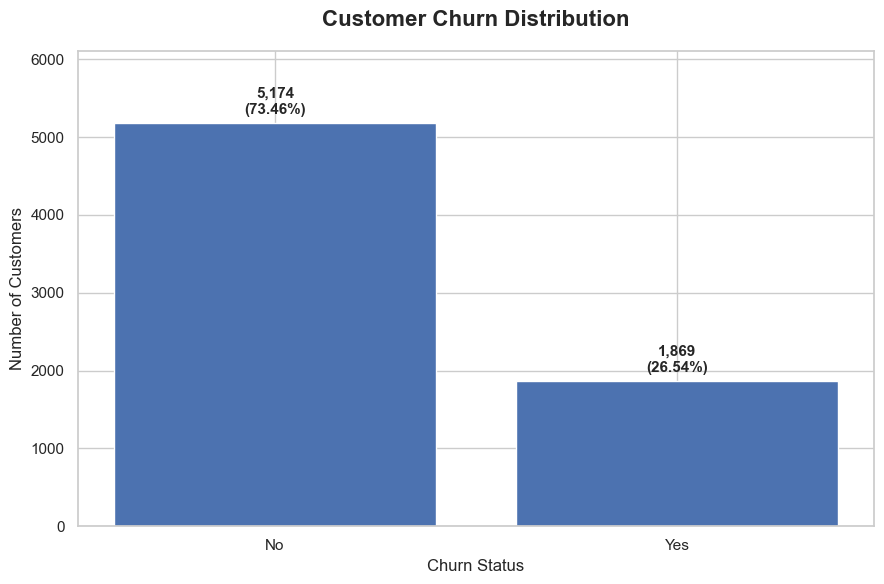

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\01_customer_churn_distribution.png


In [13]:
# Define the project and images folders

project_path = Path(
    r"C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence"
)

images_path = (
    project_path
    / "images"
)

images_path.mkdir(
    parents=True,
    exist_ok=True
)


# Prepare churn counts

churn_counts = (
    df["churn_label"]
    .value_counts()
    .reindex(
        ["No", "Yes"]
    )
)


# Create the churn distribution chart

fig, ax = plt.subplots(
    figsize=(9, 6)
)


bars = ax.bar(
    churn_counts.index,
    churn_counts.values
)


# Add customer counts and percentages

for bar, count in zip(
    bars,
    churn_counts.values
):

    percentage = (
        count
        / total_customers
        * 100
    )

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 80,

        f"{count:,}\n({percentage:.2f}%)",

        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# Format the chart

ax.set_title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Churn Status",
    fontsize=12
)

ax.set_ylabel(
    "Number of Customers",
    fontsize=12
)

ax.set_ylim(
    0,
    churn_counts.max() * 1.18
)

plt.tight_layout()


# Save the chart

chart_path = (
    images_path
    / "01_customer_churn_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"Chart saved successfully:\n"
    f"{chart_path}"
)

## 2. Churn Analysis by Contract Type

This section evaluates customer churn across different contract types to determine whether contract commitment is associated with customer retention.

In [14]:
# Create a churn summary by contract type

contract_summary = (

    df.groupby(
        "contract"
    )

    .agg(

        total_customers=(
            "customer_id",
            "count"
        ),

        churned_customers=(
            "churn_value",
            "sum"
        ),

        average_tenure_months=(
            "tenure_months",
            "mean"
        ),

        average_monthly_charges=(
            "monthly_charges",
            "mean"
        )

    )

    .reset_index()

)


# Calculate churn rate

contract_summary[
    "churn_rate_percentage"
] = (

    contract_summary[
        "churned_customers"
    ]

    / contract_summary[
        "total_customers"
    ]

    * 100

)


# Set the preferred contract order

contract_order = [

    "Month-to-month",

    "One year",

    "Two year"

]


contract_summary[
    "contract"
] = pd.Categorical(

    contract_summary[
        "contract"
    ],

    categories=contract_order,

    ordered=True

)


contract_summary = (

    contract_summary

    .sort_values(
        "contract"
    )

    .reset_index(
        drop=True
    )

)


# Round numerical values

contract_summary[
    [
        "average_tenure_months",
        "average_monthly_charges",
        "churn_rate_percentage"
    ]
] = (

    contract_summary[
        [
            "average_tenure_months",
            "average_monthly_charges",
            "churn_rate_percentage"
        ]
    ]

    .round(2)

)


contract_summary

,contract,total_customers,churned_customers,average_tenure_months,average_monthly_charges,churn_rate_percentage
0,Month-to-month,3875,1655,18.04,66.40,42.71
1,One year,1473,166,42.04,65.05,11.27
2,Two year,1695,48,56.74,60.77,2.83


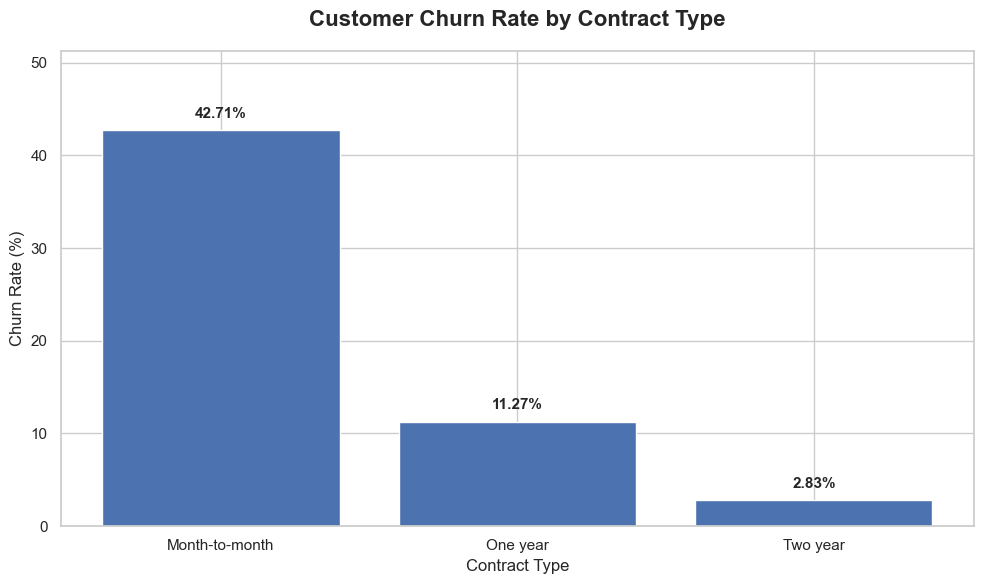

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\02_churn_rate_by_contract.png


In [15]:
# Create a churn-rate chart by contract type

fig, ax = plt.subplots(
    figsize=(10, 6)
)


bars = ax.bar(

    contract_summary[
        "contract"
    ].astype(str),

    contract_summary[
        "churn_rate_percentage"
    ]

)


# Add churn-rate labels above the bars

for bar, rate in zip(

    bars,

    contract_summary[
        "churn_rate_percentage"
    ]

):

    ax.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 1,

        f"{rate:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )


# Format the chart

ax.set_title(

    "Customer Churn Rate by Contract Type",

    fontsize=16,

    fontweight="bold",

    pad=18

)


ax.set_xlabel(

    "Contract Type",

    fontsize=12

)


ax.set_ylabel(

    "Churn Rate (%)",

    fontsize=12

)


ax.set_ylim(

    0,

    contract_summary[
        "churn_rate_percentage"
    ].max() * 1.20

)


plt.tight_layout()


# Save the chart

contract_chart_path = (

    images_path

    / "02_churn_rate_by_contract.png"

)


plt.savefig(

    contract_chart_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(

    f"Chart saved successfully:\n"

    f"{contract_chart_path}"

)

## 3. Churn Analysis by Customer Tenure

This section analyzes customer churn across different tenure groups to identify the stages of the customer lifecycle with the highest churn risk.

In [16]:
# Create customer tenure groups

tenure_labels = [
    "0-6 Months",
    "7-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49+ Months"
]


df["tenure_group"] = pd.cut(

    df["tenure_months"],

    bins=[
        -1,
        6,
        12,
        24,
        48,
        float("inf")
    ],

    labels=tenure_labels

)


# Confirm the tenure groups

df[
    [
        "tenure_months",
        "tenure_group"
    ]
].head()

,tenure_months,tenure_group
0,2,0-6 Months
1,2,0-6 Months
2,8,7-12 Months
3,28,25-48 Months
4,49,49+ Months


In [17]:
# Create a churn summary by customer tenure group

tenure_summary = (

    df.groupby(
        "tenure_group",
        observed=False
    )

    .agg(

        total_customers=(
            "customer_id",
            "count"
        ),

        churned_customers=(
            "churn_value",
            "sum"
        ),

        average_monthly_charges=(
            "monthly_charges",
            "mean"
        )

    )

    .reset_index()

)


# Calculate churn rate

tenure_summary[
    "churn_rate_percentage"
] = (

    tenure_summary[
        "churned_customers"
    ]

    / tenure_summary[
        "total_customers"
    ]

    * 100

)


# Round numerical values

tenure_summary[
    [
        "average_monthly_charges",
        "churn_rate_percentage"
    ]
] = (

    tenure_summary[
        [
            "average_monthly_charges",
            "churn_rate_percentage"
        ]
    ]

    .round(2)

)


tenure_summary

,tenure_group,total_customers,churned_customers,average_monthly_charges,churn_rate_percentage
0,0-6 Months,1481,784,54.74,52.94
1,7-12 Months,705,253,58.95,35.89
2,13-24 Months,1024,294,61.36,28.71
3,25-48 Months,1594,325,65.93,20.39
4,49+ Months,2239,213,73.95,9.51


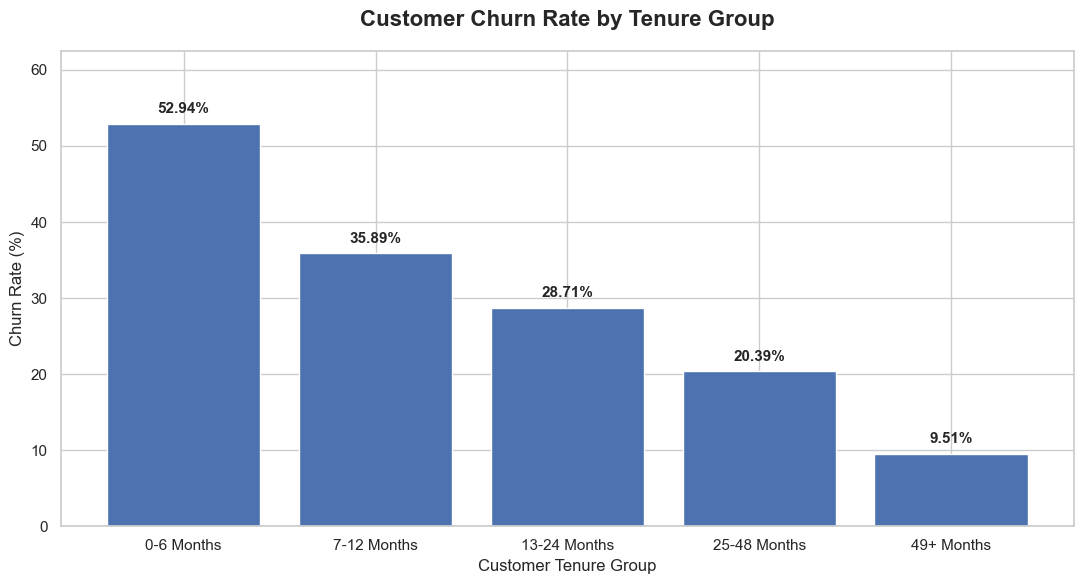

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\03_churn_rate_by_tenure_group.png


In [18]:
# Create a churn-rate chart by customer tenure group

fig, ax = plt.subplots(
    figsize=(11, 6)
)


bars = ax.bar(

    tenure_summary[
        "tenure_group"
    ].astype(str),

    tenure_summary[
        "churn_rate_percentage"
    ]

)


# Add churn-rate labels above the bars

for bar, rate in zip(

    bars,

    tenure_summary[
        "churn_rate_percentage"
    ]

):

    ax.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 1,

        f"{rate:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"

    )


# Format the chart

ax.set_title(

    "Customer Churn Rate by Tenure Group",

    fontsize=16,

    fontweight="bold",

    pad=18

)


ax.set_xlabel(

    "Customer Tenure Group",

    fontsize=12

)


ax.set_ylabel(

    "Churn Rate (%)",

    fontsize=12

)


ax.set_ylim(

    0,

    tenure_summary[
        "churn_rate_percentage"
    ].max() * 1.18

)


plt.tight_layout()


# Save the chart

tenure_chart_path = (

    images_path

    / "03_churn_rate_by_tenure_group.png"

)


plt.savefig(

    tenure_chart_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(

    f"Chart saved successfully:\n"

    f"{tenure_chart_path}"

)

## 4. Service Risk Analysis

This section evaluates customer churn across internet service types, technical support availability, and online security status to identify service-related churn patterns.

In [19]:
# Create reusable functions for churn analysis


def create_churn_summary(
    data,
    category_column
):

    summary = (

        data.groupby(
            category_column,
            dropna=False
        )

        .agg(

            total_customers=(
                "customer_id",
                "count"
            ),

            churned_customers=(
                "churn_value",
                "sum"
            ),

            average_monthly_charges=(
                "monthly_charges",
                "mean"
            )

        )

        .reset_index()

    )


    summary[
        "churn_rate_percentage"
    ] = (

        summary[
            "churned_customers"
        ]

        / summary[
            "total_customers"
        ]

        * 100

    )


    summary[
        [
            "average_monthly_charges",
            "churn_rate_percentage"
        ]
    ] = (

        summary[
            [
                "average_monthly_charges",
                "churn_rate_percentage"
            ]
        ]

        .round(2)

    )


    summary = (

        summary

        .sort_values(
            "churn_rate_percentage",
            ascending=False
        )

        .reset_index(
            drop=True
        )

    )


    return summary



def plot_churn_rate(

    summary,

    category_column,

    chart_title,

    x_axis_label,

    file_name

):

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    bars = ax.bar(

        summary[
            category_column
        ].astype(str),

        summary[
            "churn_rate_percentage"
        ]

    )


    for bar, rate in zip(

        bars,

        summary[
            "churn_rate_percentage"
        ]

    ):

        ax.text(

            bar.get_x()
            + bar.get_width() / 2,

            bar.get_height()
            + 1,

            f"{rate:.2f}%",

            ha="center",

            va="bottom",

            fontsize=11,

            fontweight="bold"

        )


    ax.set_title(

        chart_title,

        fontsize=16,

        fontweight="bold",

        pad=18

    )


    ax.set_xlabel(

        x_axis_label,

        fontsize=12

    )


    ax.set_ylabel(

        "Churn Rate (%)",

        fontsize=12

    )


    ax.set_ylim(

        0,

        summary[
            "churn_rate_percentage"
        ].max() * 1.22

    )


    plt.tight_layout()


    chart_path = (

        images_path

        / file_name

    )


    plt.savefig(

        chart_path,

        dpi=300,

        bbox_inches="tight"

    )


    plt.show()


    print(

        f"Chart saved successfully:\n"

        f"{chart_path}"

    )

In [20]:
# Analyze churn by internet service type

internet_service_summary = (

    create_churn_summary(

        df,

        "internet_service"

    )

)


internet_service_summary

,internet_service,total_customers,churned_customers,average_monthly_charges,churn_rate_percentage
0,Fiber optic,3096,1297,91.50,41.89
1,DSL,2421,459,58.10,18.96
2,No,1526,113,21.08,7.40


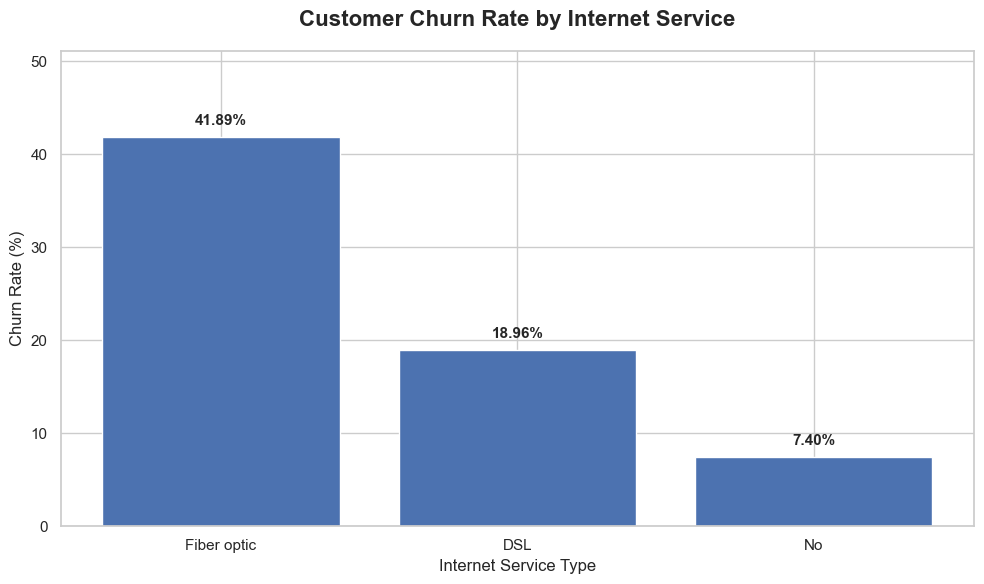

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\04_churn_rate_by_internet_service.png


In [21]:
# Visualize churn rate by internet service type

plot_churn_rate(

    summary=internet_service_summary,

    category_column="internet_service",

    chart_title=(
        "Customer Churn Rate "
        "by Internet Service"
    ),

    x_axis_label=(
        "Internet Service Type"
    ),

    file_name=(
        "04_churn_rate_by_"
        "internet_service.png"
    )

)

In [22]:
# Analyze churn by technical support status

tech_support_summary = (

    create_churn_summary(

        df,

        "tech_support"

    )

)


tech_support_summary

,tech_support,total_customers,churned_customers,average_monthly_charges,churn_rate_percentage
0,No,3473,1446,74.59,41.64
1,Yes,2044,310,80.68,15.17
2,No internet service,1526,113,21.08,7.40


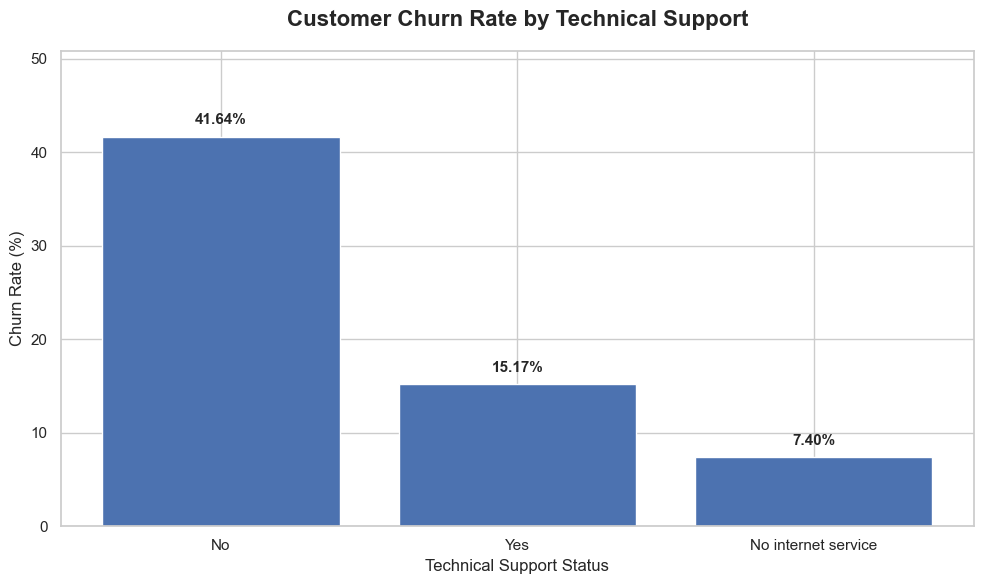

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\05_churn_rate_by_tech_support.png


In [23]:
# Visualize churn rate by technical support status

plot_churn_rate(

    summary=tech_support_summary,

    category_column="tech_support",

    chart_title=(
        "Customer Churn Rate "
        "by Technical Support"
    ),

    x_axis_label=(
        "Technical Support Status"
    ),

    file_name=(
        "05_churn_rate_by_"
        "tech_support.png"
    )

)

In [24]:
# Analyze churn by online security status

online_security_summary = (

    create_churn_summary(

        df,

        "online_security"

    )

)


online_security_summary

,online_security,total_customers,churned_customers,average_monthly_charges,churn_rate_percentage
0,No,3498,1461,75.69,41.77
1,Yes,2019,295,78.84,14.61
2,No internet service,1526,113,21.08,7.40


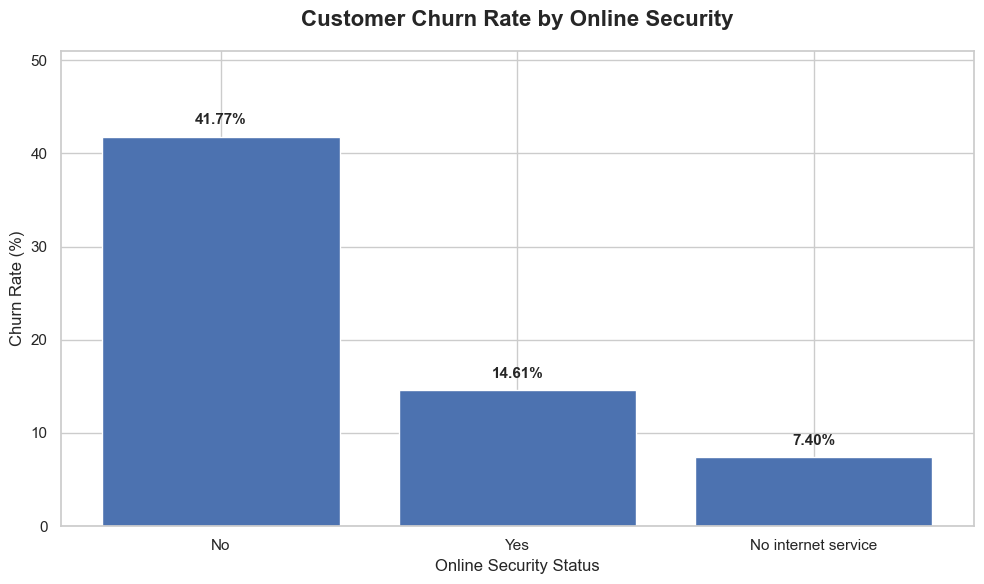

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\06_churn_rate_by_online_security.png


In [25]:
# Visualize churn rate by online security status

plot_churn_rate(

    summary=online_security_summary,

    category_column="online_security",

    chart_title=(
        "Customer Churn Rate "
        "by Online Security"
    ),

    x_axis_label=(
        "Online Security Status"
    ),

    file_name=(
        "06_churn_rate_by_"
        "online_security.png"
    )

)

## 5. Billing and Payment Analysis

This section examines customer churn across payment methods, paperless billing preferences, and automatic versus manual payment groups.

In [26]:
# Analyze churn by payment method

payment_method_summary = (

    create_churn_summary(

        df,

        "payment_method"

    )

)


payment_method_summary

,payment_method,total_customers,churned_customers,average_monthly_charges,churn_rate_percentage
0,Electronic check,2365,1071,76.26,45.29
1,Mailed check,1612,308,43.92,19.11
2,Bank transfer (automatic),1544,258,67.19,16.71
3,Credit card (automatic),1522,232,66.51,15.24


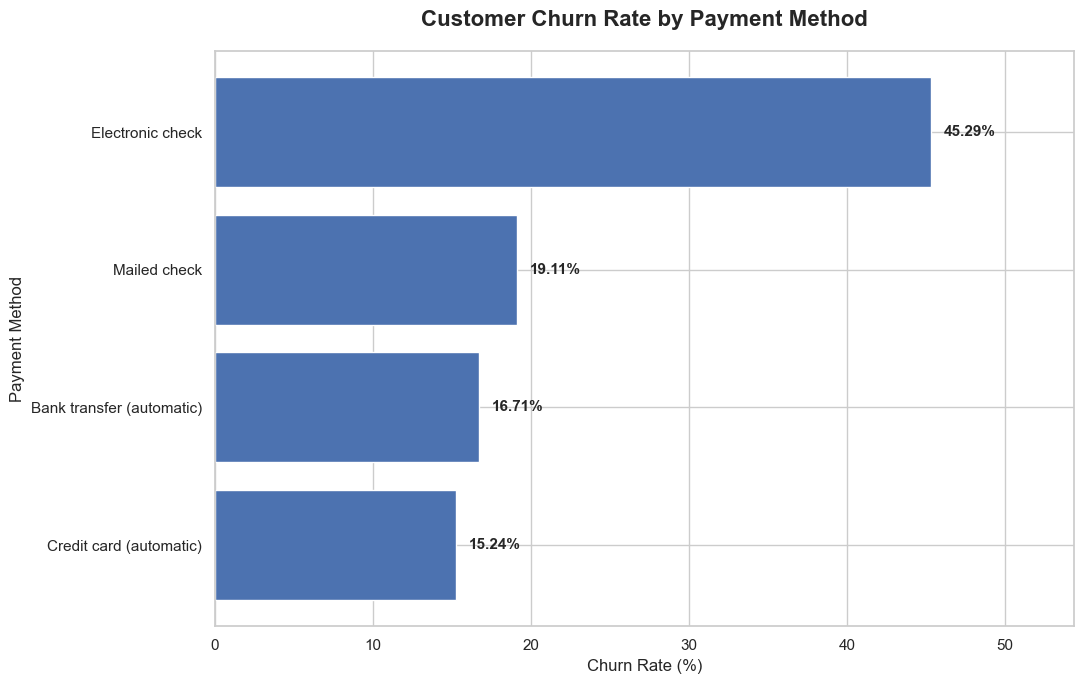

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\07_churn_rate_by_payment_method.png


In [27]:
# Create a horizontal churn-rate chart by payment method

payment_chart_data = (

    payment_method_summary

    .sort_values(

        "churn_rate_percentage",

        ascending=True

    )

)


fig, ax = plt.subplots(

    figsize=(11, 7)

)


bars = ax.barh(

    payment_chart_data[
        "payment_method"
    ],

    payment_chart_data[
        "churn_rate_percentage"
    ]

)


# Add churn-rate labels

for bar, rate in zip(

    bars,

    payment_chart_data[
        "churn_rate_percentage"
    ]

):

    ax.text(

        bar.get_width()
        + 0.8,

        bar.get_y()
        + bar.get_height() / 2,

        f"{rate:.2f}%",

        va="center",

        fontsize=11,

        fontweight="bold"

    )


# Format the chart

ax.set_title(

    "Customer Churn Rate by Payment Method",

    fontsize=16,

    fontweight="bold",

    pad=18

)


ax.set_xlabel(

    "Churn Rate (%)",

    fontsize=12

)


ax.set_ylabel(

    "Payment Method",

    fontsize=12

)


ax.set_xlim(

    0,

    payment_chart_data[
        "churn_rate_percentage"
    ].max() * 1.20

)


plt.tight_layout()


# Save the chart

payment_method_chart_path = (

    images_path

    / "07_churn_rate_by_payment_method.png"

)


plt.savefig(

    payment_method_chart_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(

    f"Chart saved successfully:\n"

    f"{payment_method_chart_path}"

)

In [28]:
# Analyze churn by paperless billing status

paperless_billing_summary = (

    create_churn_summary(

        df,

        "paperless_billing"

    )

)


paperless_billing_summary

,paperless_billing,total_customers,churned_customers,average_monthly_charges,churn_rate_percentage
0,Yes,4171,1400,73.55,33.57
1,No,2872,469,51.99,16.33


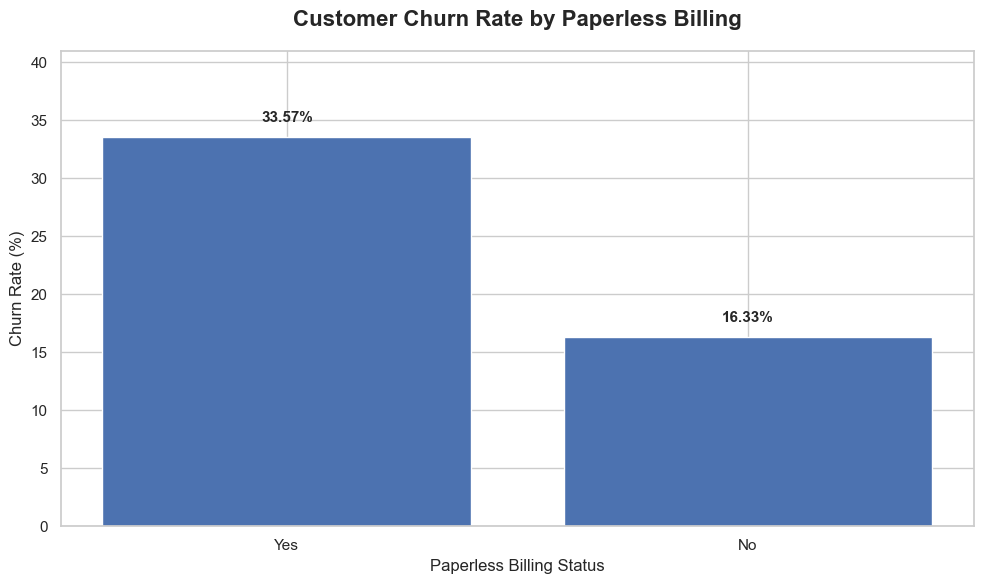

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\08_churn_rate_by_paperless_billing.png


In [29]:
# Visualize churn rate by paperless billing status

plot_churn_rate(

    summary=paperless_billing_summary,

    category_column="paperless_billing",

    chart_title=(

        "Customer Churn Rate "

        "by Paperless Billing"

    ),

    x_axis_label=(

        "Paperless Billing Status"

    ),

    file_name=(

        "08_churn_rate_by_"

        "paperless_billing.png"

    )

)

In [30]:
# Create automatic and manual payment groups

automatic_payment_methods = [

    "Bank transfer (automatic)",

    "Credit card (automatic)"

]


df["payment_group"] = np.where(

    df["payment_method"]

    .isin(

        automatic_payment_methods

    ),

    "Automatic Payment",

    "Manual Payment"

)


# Preview the payment groups

df[
    [

        "payment_method",

        "payment_group"

    ]

].head()

,payment_method,payment_group
0,Mailed check,Manual Payment
1,Electronic check,Manual Payment
2,Electronic check,Manual Payment
3,Electronic check,Manual Payment
4,Bank transfer (automatic),Automatic Payment


In [31]:
# Analyze churn by payment group

payment_group_summary = (

    df.groupby(

        "payment_group"

    )

    .agg(

        total_customers=(

            "customer_id",

            "count"

        ),

        churned_customers=(

            "churn_value",

            "sum"

        ),

        average_tenure_months=(

            "tenure_months",

            "mean"

        ),

        average_monthly_charges=(

            "monthly_charges",

            "mean"

        )

    )

    .reset_index()

)


# Calculate churn rate

payment_group_summary[

    "churn_rate_percentage"

] = (

    payment_group_summary[

        "churned_customers"

    ]

    / payment_group_summary[

        "total_customers"

    ]

    * 100

)


# Round numerical columns

payment_group_summary[

    [

        "average_tenure_months",

        "average_monthly_charges",

        "churn_rate_percentage"

    ]

] = (

    payment_group_summary[

        [

            "average_tenure_months",

            "average_monthly_charges",

            "churn_rate_percentage"

        ]

    ]

    .round(2)

)


payment_group_summary

,payment_group,total_customers,churned_customers,average_tenure_months,average_monthly_charges,churn_rate_percentage
0,Automatic Payment,3066,490,43.46,66.85,15.98
1,Manual Payment,3977,1379,23.82,63.15,34.67


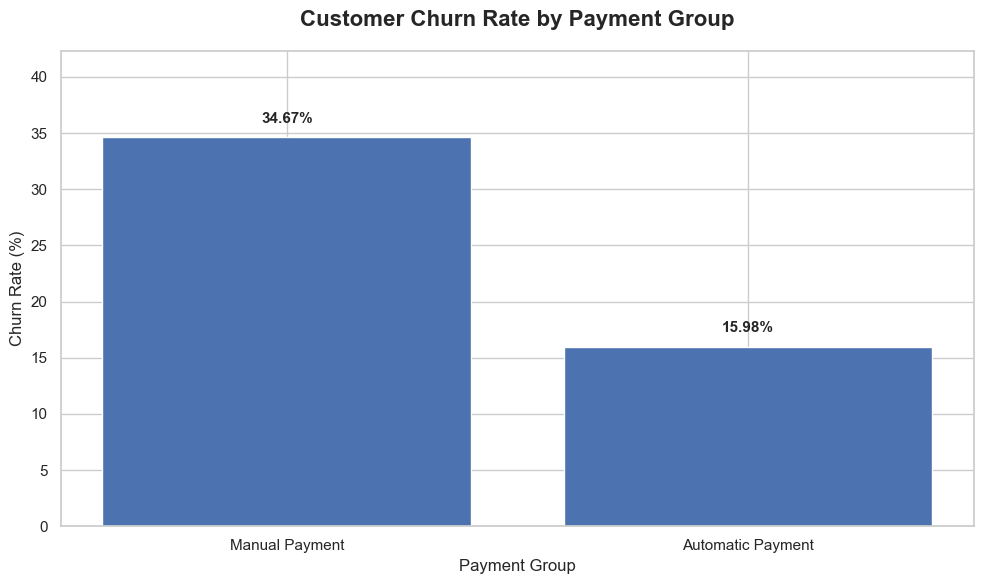

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\09_churn_rate_by_payment_group.png


In [32]:
# Visualize churn rate by payment group

payment_group_summary = (

    payment_group_summary

    .sort_values(

        "churn_rate_percentage",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)


plot_churn_rate(

    summary=payment_group_summary,

    category_column="payment_group",

    chart_title=(

        "Customer Churn Rate "

        "by Payment Group"

    ),

    x_axis_label=(

        "Payment Group"

    ),

    file_name=(

        "09_churn_rate_by_"

        "payment_group.png"

    )

)

## 6. Customer Churn Reason Analysis

This section examines the reported reasons for customer churn and groups them into broader business categories to identify the main drivers of customer loss.

In [33]:
# Create a separate dataset for churned customers

churned_df = (

    df.loc[
        df["churn_value"] == 1
    ]

    .copy()

)


print(
    f"Total churned customers: "
    f"{len(churned_df):,}"
)

Total churned customers: 1,869


In [34]:
# Calculate the most frequently reported churn reasons

top_churn_reasons = (

    churned_df[
        "churn_reason"
    ]

    .value_counts()

    .rename_axis(
        "churn_reason"
    )

    .reset_index(
        name="churned_customers"
    )

)


top_churn_reasons[
    "share_percentage"
] = (

    top_churn_reasons[
        "churned_customers"
    ]

    / len(churned_df)

    * 100

)


top_churn_reasons[
    "share_percentage"
] = (

    top_churn_reasons[
        "share_percentage"
    ]

    .round(2)

)


top_churn_reasons.head(10)

,churn_reason,churned_customers,share_percentage
0,Attitude of support person,192,10.27
1,Competitor offered higher download speeds,189,10.11
2,Competitor offered more data,162,8.67
3,Don't know,154,8.24
4,Competitor made better offer,140,7.49
5,Attitude of service provider,135,7.22
6,Competitor had better devices,130,6.96
7,Network reliability,103,5.51
8,Product dissatisfaction,102,5.46
9,Price too high,98,5.24


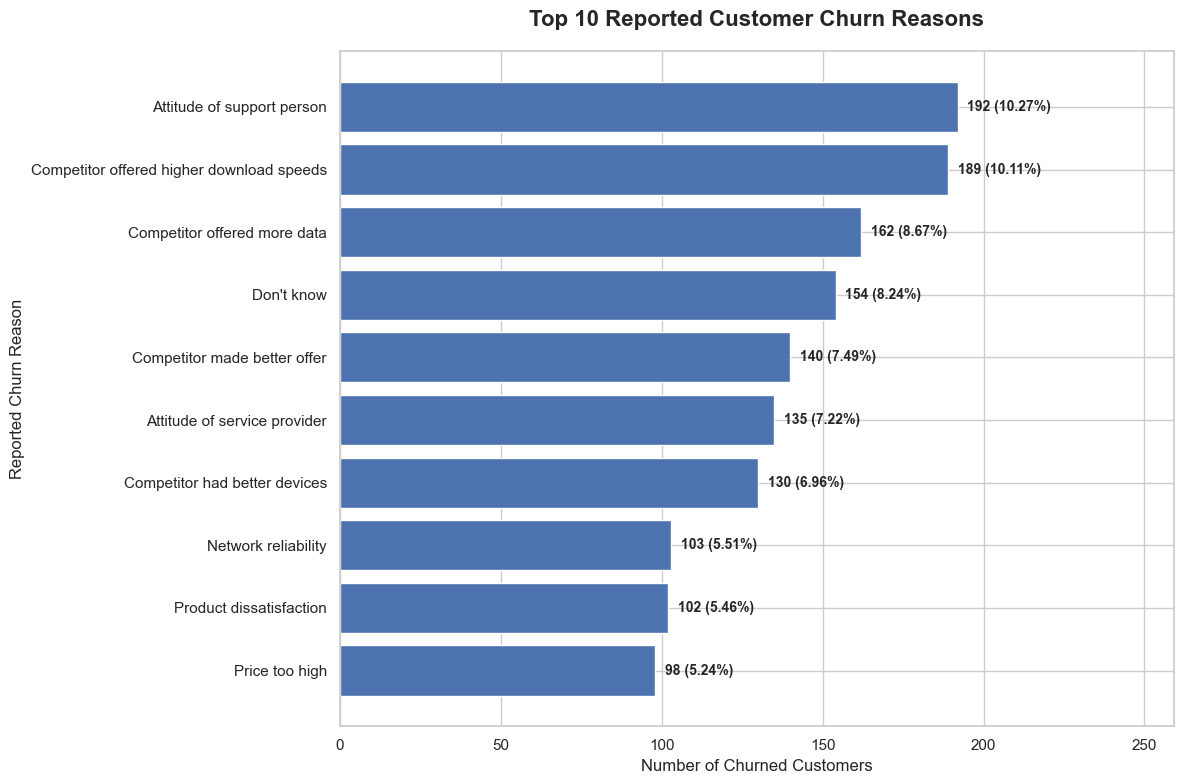

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\10_top_customer_churn_reasons.png


In [35]:
# Prepare the top 10 churn reasons for visualization

top_10_reason_chart = (

    top_churn_reasons

    .head(10)

    .sort_values(

        "churned_customers",

        ascending=True

    )

)


# Create the chart

fig, ax = plt.subplots(

    figsize=(12, 8)

)


bars = ax.barh(

    top_10_reason_chart[
        "churn_reason"
    ],

    top_10_reason_chart[
        "churned_customers"
    ]

)


# Add customer counts and percentages

for bar, count, percentage in zip(

    bars,

    top_10_reason_chart[
        "churned_customers"
    ],

    top_10_reason_chart[
        "share_percentage"
    ]

):

    ax.text(

        bar.get_width()
        + 3,

        bar.get_y()
        + bar.get_height() / 2,

        f"{count:,} ({percentage:.2f}%)",

        va="center",

        fontsize=10,

        fontweight="bold"

    )


# Format the chart

ax.set_title(

    "Top 10 Reported Customer Churn Reasons",

    fontsize=16,

    fontweight="bold",

    pad=18

)


ax.set_xlabel(

    "Number of Churned Customers",

    fontsize=12

)


ax.set_ylabel(

    "Reported Churn Reason",

    fontsize=12

)


ax.set_xlim(

    0,

    top_10_reason_chart[
        "churned_customers"
    ].max() * 1.35

)


plt.tight_layout()


# Save the chart

top_reasons_chart_path = (

    images_path

    / "10_top_customer_churn_reasons.png"

)


plt.savefig(

    top_reasons_chart_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(

    f"Chart saved successfully:\n"

    f"{top_reasons_chart_path}"

)

In [36]:
# Convert churn reasons into broader business categories

reason_text = (

    churned_df[
        "churn_reason"
    ]

    .fillna("")

    .str.lower()

)


conditions = [

    reason_text.str.contains(
        "competitor",
        regex=False
    ),

    reason_text.str.contains(
        r"price|charge|affordable",
        regex=True
    ),

    reason_text.str.contains(
        r"support|attitude|self-service|service provider",
        regex=True
    ),

    reason_text.str.contains(
        r"network|reliability|product|service|download|upload|device|data",
        regex=True
    ),

    reason_text.str.contains(
        r"moved|deceased",
        regex=True
    )

]


categories = [

    "Competitor",

    "Price and Charges",

    "Service and Support",

    "Product and Network",

    "Customer Circumstances"

]


churned_df[
    "churn_reason_category"
] = np.select(

    conditions,

    categories,

    default="Other or Unknown"

)


churned_df[
    [
        "churn_reason",
        "churn_reason_category"
    ]
].head()

,churn_reason,churn_reason_category
0,Competitor made better offer,Competitor
1,Moved,Customer Circumstances
2,Moved,Customer Circumstances
3,Moved,Customer Circumstances
4,Competitor had better devices,Competitor


In [37]:
# Summarize churned customers by reason category

reason_category_summary = (

    churned_df[
        "churn_reason_category"
    ]

    .value_counts()

    .rename_axis(
        "churn_reason_category"
    )

    .reset_index(
        name="churned_customers"
    )

)


reason_category_summary[
    "share_percentage"
] = (

    reason_category_summary[
        "churned_customers"
    ]

    / len(churned_df)

    * 100

)


reason_category_summary[
    "share_percentage"
] = (

    reason_category_summary[
        "share_percentage"
    ]

    .round(2)

)


reason_category_summary

,churn_reason_category,churned_customers,share_percentage
0,Competitor,621,33.23
1,Service and Support,454,24.29
2,Product and Network,338,18.08
3,Price and Charges,243,13.00
4,Other or Unknown,154,8.24
5,Customer Circumstances,59,3.16


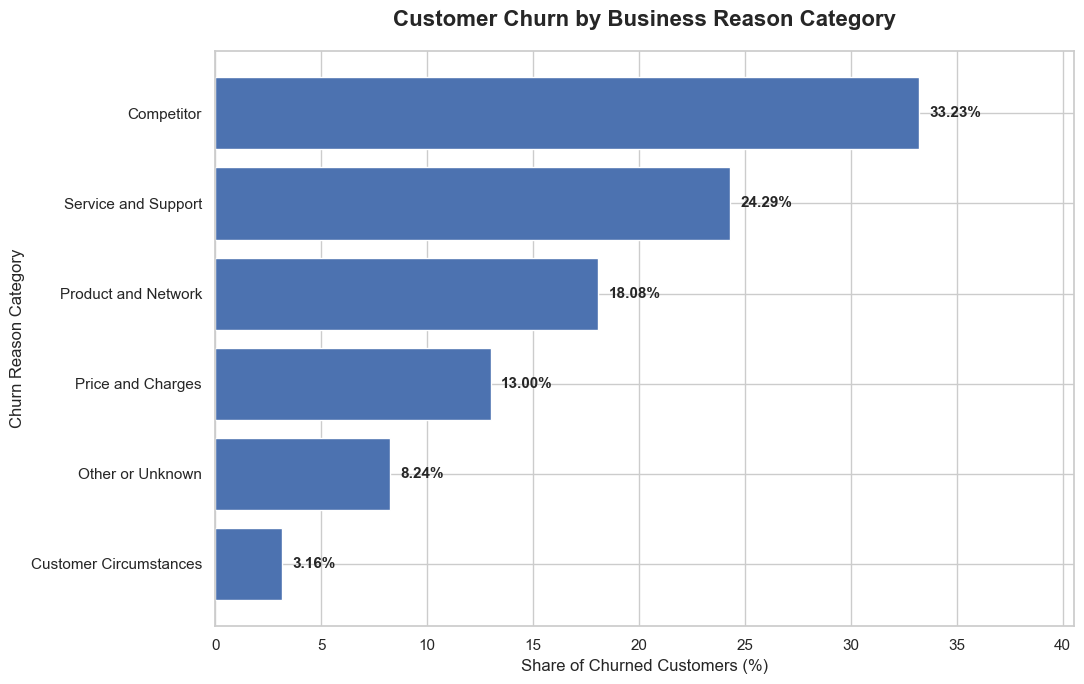

Chart saved successfully:
C:\Users\hp15-da\Desktop\معرض عمال\Customer_Churn_Intelligence\images\11_churn_reason_categories.png


In [38]:
# Prepare churn-reason categories for visualization

reason_category_chart = (

    reason_category_summary

    .sort_values(

        "churned_customers",

        ascending=True

    )

)


# Create the chart

fig, ax = plt.subplots(

    figsize=(11, 7)

)


bars = ax.barh(

    reason_category_chart[
        "churn_reason_category"
    ],

    reason_category_chart[
        "share_percentage"
    ]

)


# Add percentage labels

for bar, percentage in zip(

    bars,

    reason_category_chart[
        "share_percentage"
    ]

):

    ax.text(

        bar.get_width()
        + 0.5,

        bar.get_y()
        + bar.get_height() / 2,

        f"{percentage:.2f}%",

        va="center",

        fontsize=11,

        fontweight="bold"

    )


# Format the chart

ax.set_title(

    "Customer Churn by Business Reason Category",

    fontsize=16,

    fontweight="bold",

    pad=18

)


ax.set_xlabel(

    "Share of Churned Customers (%)",

    fontsize=12

)


ax.set_ylabel(

    "Churn Reason Category",

    fontsize=12

)


ax.set_xlim(

    0,

    reason_category_chart[
        "share_percentage"
    ].max() * 1.22

)


plt.tight_layout()


# Save the chart

reason_category_chart_path = (

    images_path

    / "11_churn_reason_categories.png"

)


plt.savefig(

    reason_category_chart_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


print(

    f"Chart saved successfully:\n"

    f"{reason_category_chart_path}"

)

## 7. Key Exploratory Data Analysis Findings

The exploratory analysis identified several clear customer patterns associated with churn. These findings describe observed relationships within the dataset and should not be interpreted as proof of direct causation.

### Overall Churn

- The dataset contains **7,043 customers**.
- A total of **1,869 customers churned**, resulting in an overall churn rate of **26.54%**.
- Approximately one out of every four customers left the company.

### Contract Type

- Customers with **month-to-month contracts** recorded the highest churn rate at **42.71%**.
- Churn declined substantially among customers with longer contractual commitments:
  - One-year contracts: **11.27%**
  - Two-year contracts: **2.83%**
- Approximately **88.6% of all churned customers** were subscribed to month-to-month contracts.

### Customer Tenure

- Customers within their first **0–6 months** had the highest churn rate at **52.94%**.
- The churn rate declined consistently as customer tenure increased.
- Customers with more than **49 months** of tenure recorded a churn rate of only **9.51%**.
- Early customer engagement and onboarding appear to be important retention opportunities.

### Internet and Support Services

- Fiber optic customers recorded a churn rate of **41.89%**, compared with **18.96%** among DSL customers.
- Customers without technical support had a churn rate of **41.64%**, compared with **15.17%** among customers with technical support.
- Customers without online security recorded a churn rate of **41.77%**, compared with **14.61%** among subscribed customers.
- These patterns suggest that service experience, support availability, pricing, and product configuration should be examined together.

### Billing and Payment

- Electronic check users recorded the highest payment-method churn rate at **45.29%**.
- Customers using manual payment methods had a churn rate of **34.67%**, compared with **15.98%** among automatic-payment customers.
- Customers using paperless billing showed a higher observed churn rate; however, this group also had higher average monthly charges and may differ across other customer characteristics.

### Customer Profile

- Senior customers recorded a higher observed churn rate than non-senior customers.
- Customers without partners or dependents showed higher churn rates and shorter average customer tenure.
- Gender showed only a very small difference in churn rates and did not appear to be a meaningful churn differentiator.

### Reported Churn Reasons

- Competitor-related reasons represented **33.23%** of reported churn.
- Service and support issues accounted for **24.29%**.
- Product and network concerns represented **18.08%**.
- Price and charge concerns accounted for **13.00%**.
- Competitor, service, support, product, and network categories together represented approximately **75.60%** of reported customer churn.

### Preliminary High-Risk Customer Profile

The exploratory results suggest that higher-risk customers are more likely to have several of the following characteristics:

- Short customer tenure
- Month-to-month contracts
- Fiber optic service
- No technical support
- No online security
- Electronic check or manual payment
- Higher monthly charges

These findings will be evaluated further using a machine-learning model with separate training and testing data.

### Data Quality and Modeling Note

The missing values in the `churn_reason` column are expected because retained customers do not have a reported reason for leaving.

To prevent data leakage, the following variables will not be used as predictive model inputs:

- `churn_label`
- `churn_score`
- `churn_reason`

The target variable for machine learning will be:

- `churn_value`